In [1]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import os
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge

from mess3 import (
    COMPONENT_PARAMS, COMPONENT_WEIGHTS,
    make_transition_matrix, make_emission_matrix, make_observation_matrices,
    generate_sequences, compute_belief_states, verify_data_generation,
)
from model import Transformer, ModelConfig
from train import train, compute_theoretical_loss, get_device
from analysis import (
    collect_activations, pca_analysis, linear_regression_beliefs,
    barycentric_to_cartesian, draw_simplex_outline, rgb_from_belief,
    compute_per_component_theoretical_loss,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

device = get_device()
print(f'Device: {device}')
os.makedirs('outputs', exist_ok=True)

Device: mps


## Data Verification

In [2]:
verify_data_generation()

Data generation verification:
  observation_matrices: OK
  token_frequencies: [0.334028 0.33298  0.332992]
  component_frequencies: [0.3303 0.3317 0.338 ]
  beliefs_sum_to_1: OK
  beliefs_nonneg: OK
  initial_belief_uniform: OK


{'observation_matrices': 'OK',
 'token_frequencies': array([0.334028, 0.33298 , 0.332992]),
 'component_frequencies': array([0.3303, 0.3317, 0.338 ]),
 'beliefs_sum_to_1': 'OK',
 'beliefs_nonneg': 'OK',
 'initial_belief_uniform': 'OK'}

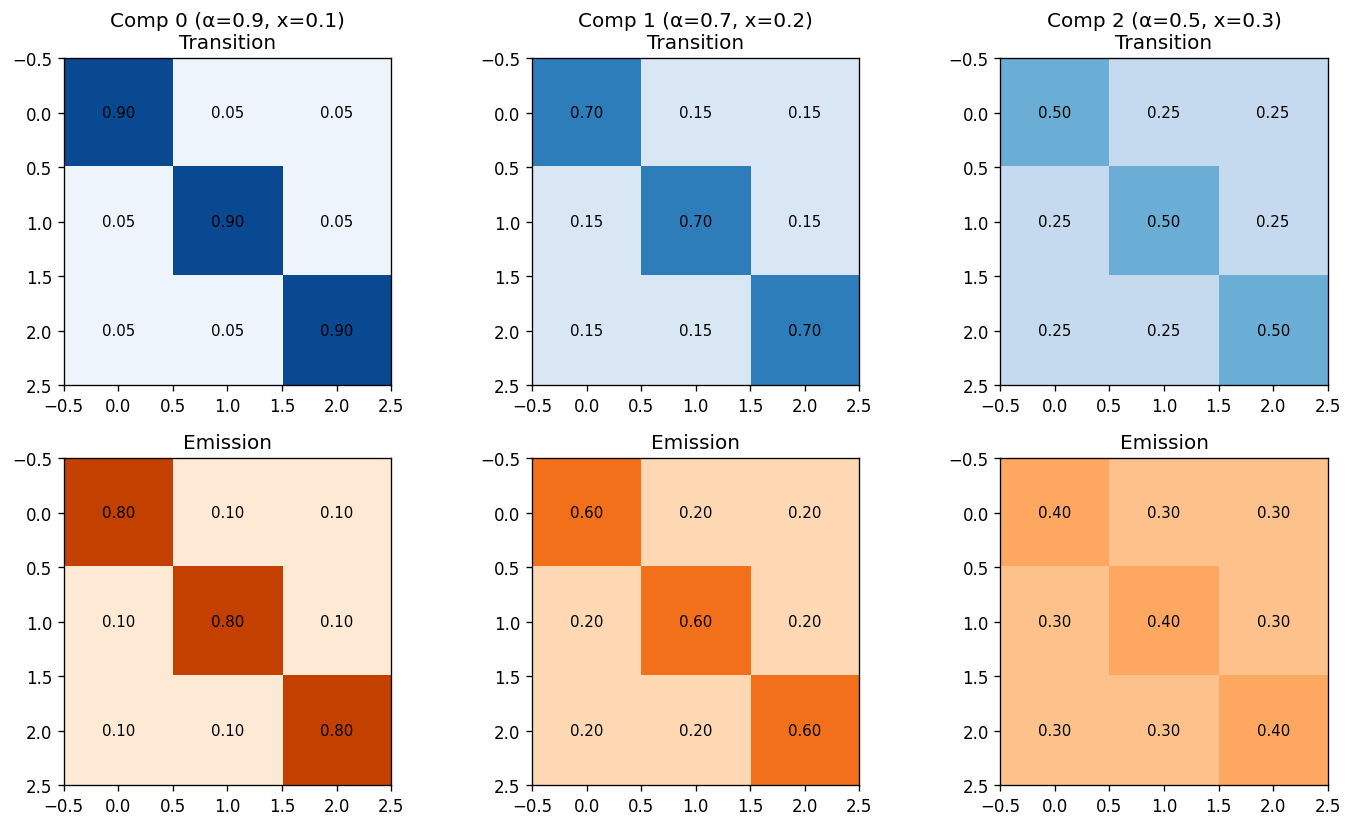

In [3]:
# Transition and emission matrices
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
comp_names = ['Comp 0 (α=0.9, x=0.1)', 'Comp 1 (α=0.7, x=0.2)', 'Comp 2 (α=0.5, x=0.3)']

for k, (alpha, x) in enumerate(COMPONENT_PARAMS):
    T = make_transition_matrix(alpha)
    E = make_emission_matrix(x)
    for row, (mat, cmap, title) in enumerate([(T, 'Blues', 'Transition'), (E, 'Oranges', 'Emission')]):
        ax = axes[row, k]
        ax.imshow(mat, cmap=cmap, vmin=0, vmax=1)
        ax.set_title(f'{comp_names[k]}\n{title}' if row == 0 else title)
        for i in range(3):
            for j in range(3):
                ax.text(j, i, f'{mat[i,j]:.2f}', ha='center', va='center', fontsize=9)
plt.tight_layout()
plt.show()

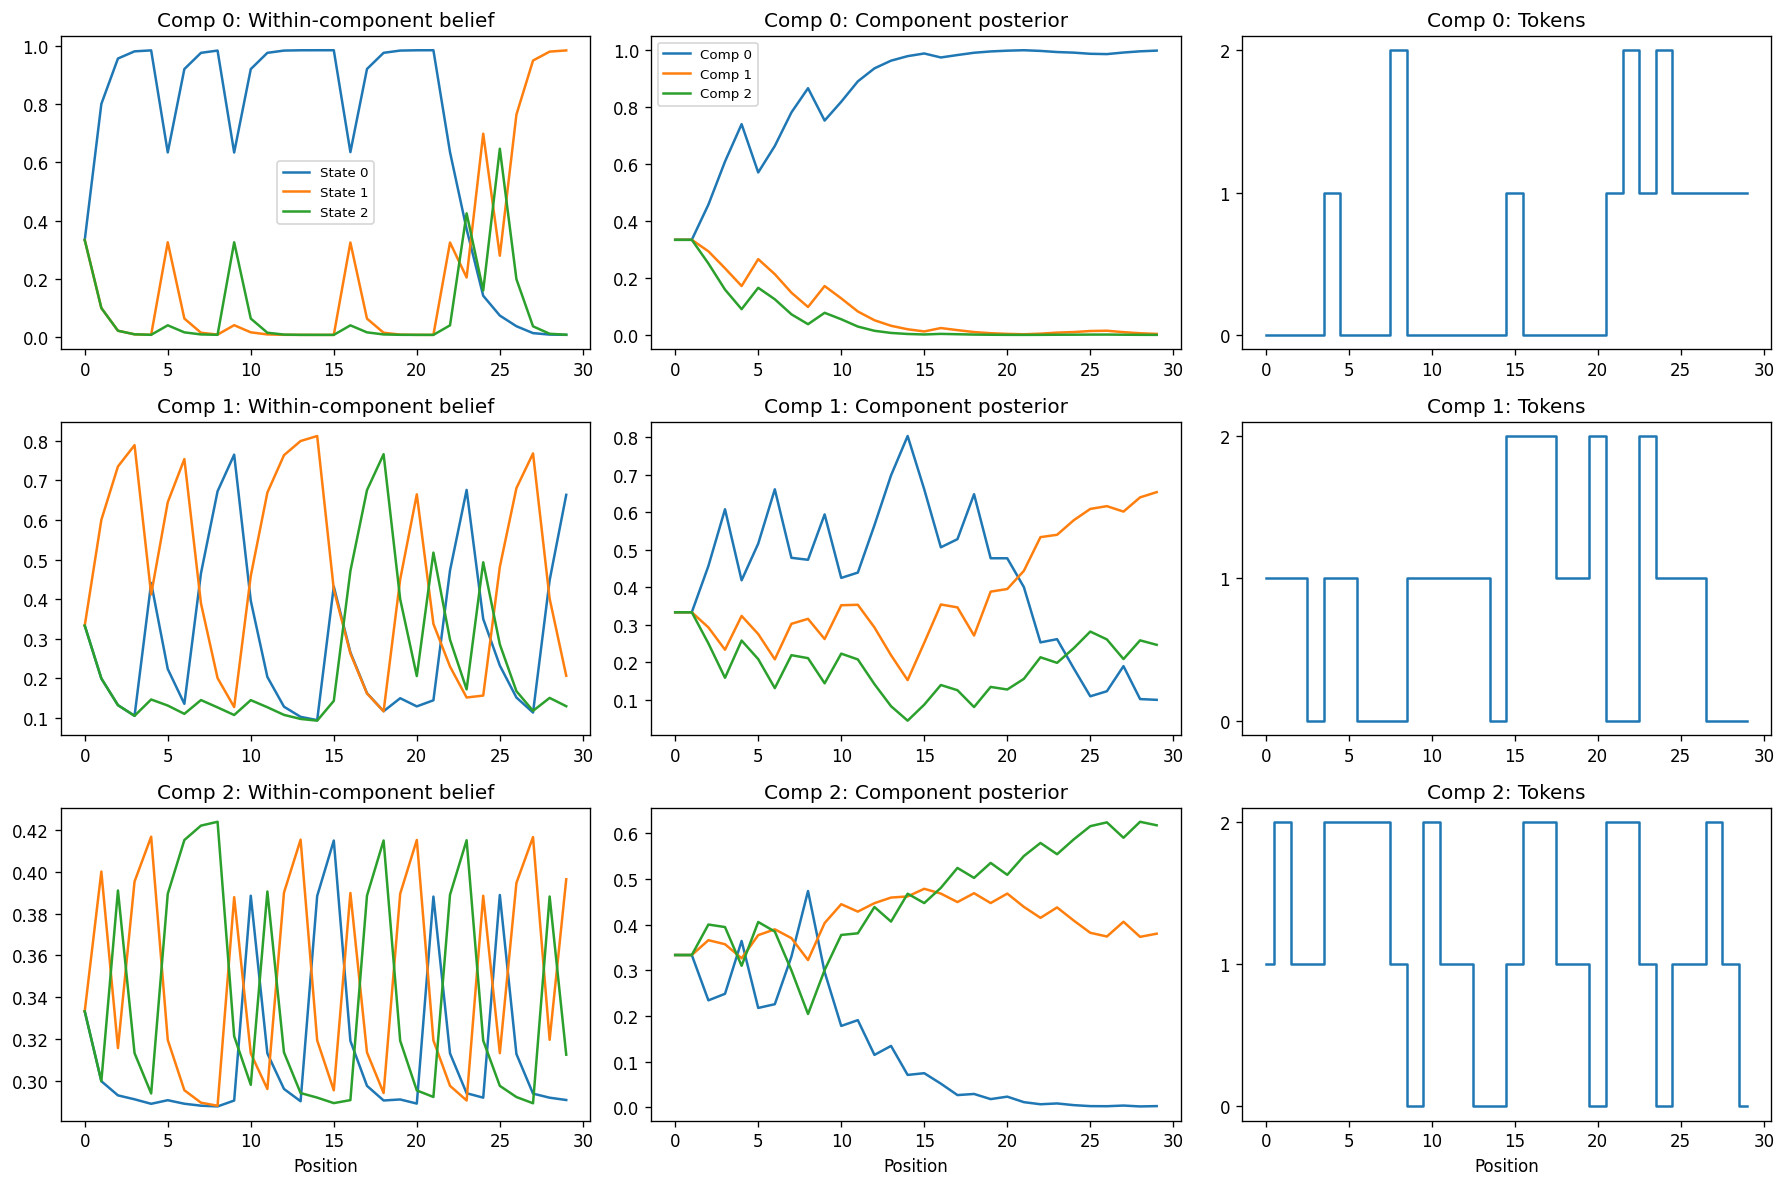

In [4]:
# Belief evolution for sample sequences
seqs, comp_ids = generate_sequences(9, 30, rng=np.random.default_rng(42))
beliefs = compute_belief_states(seqs, comp_ids)

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for k in range(3):
    idx = np.where(comp_ids == k)[0][0]
    for s in range(3):
        axes[k, 0].plot(beliefs['within_component'][idx, :, s], label=f'State {s}')
    axes[k, 0].set_title(f'Comp {k}: Within-component belief')
    if k == 0: axes[k, 0].legend(fontsize=8)
    for c in range(3):
        axes[k, 1].plot(beliefs['component_posterior'][idx, :, c], label=f'Comp {c}')
    axes[k, 1].set_title(f'Comp {k}: Component posterior')
    if k == 0: axes[k, 1].legend(fontsize=8)
    axes[k, 2].step(range(30), seqs[idx], where='mid')
    axes[k, 2].set_title(f'Comp {k}: Tokens'); axes[k, 2].set_yticks([0, 1, 2])
for ax in axes[-1]: ax.set_xlabel('Position')
plt.tight_layout()
plt.show()

## Training

In [5]:
print('Computing Bayes-optimal loss...')
theoretical_loss = compute_theoretical_loss(n_samples=25000)
print(f'Per-position: {np.round(theoretical_loss, 4)}')
print(f'Mean: {theoretical_loss.mean():.4f}')

Computing Bayes-optimal loss...
Per-position: [1.069  1.0573 1.05   1.0489 1.043  1.0453 1.0453 1.0458 1.0468 1.0393
 1.0394 1.0413]
Mean: 1.0476


In [6]:
config = ModelConfig()
model = Transformer(config)
print(f'Parameters: {model.count_parameters():,}')

checkpoint_path = 'outputs/checkpoint.pt'
if os.path.isfile(checkpoint_path):
    ckpt = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    if 'history' in ckpt:
        history = ckpt['history']
    print(f'Loaded checkpoint from {checkpoint_path}')
else:
    model, history = train(model, config, n_steps=25000, batch_size=64, lr=1e-3, device=device)
    torch.save({'model_state_dict': model.state_dict(), 'history': history}, checkpoint_path)
    print(f'Saved checkpoint to {checkpoint_path}')

Parameters: 51,264
Loaded checkpoint from outputs/checkpoint.pt


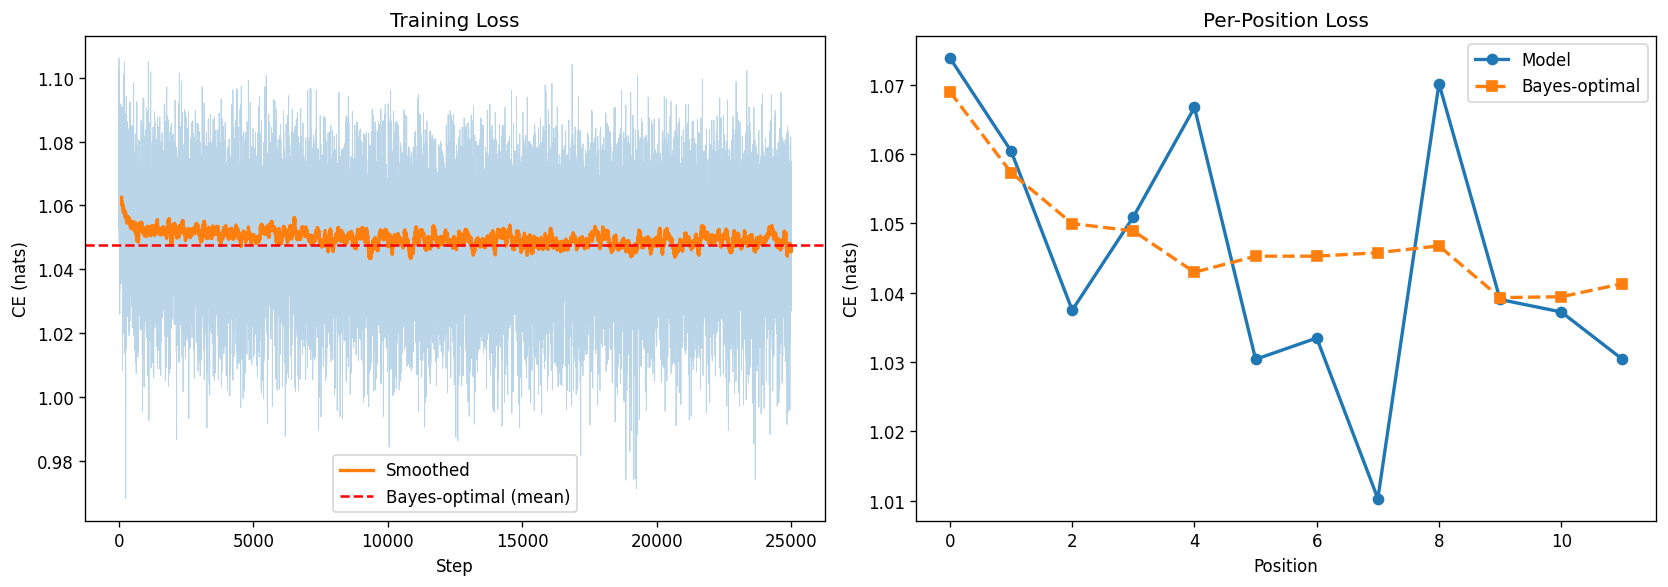

In [7]:
# Training loss
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(history['loss'], alpha=0.3, linewidth=0.5)
smoothed = np.convolve(history['loss'], np.ones(100)/100, mode='valid')
ax.plot(range(99, len(history['loss'])), smoothed, linewidth=2, label='Smoothed')
ax.axhline(theoretical_loss.mean(), color='red', linestyle='--', label='Bayes-optimal (mean)')
ax.set_xlabel('Step'); ax.set_ylabel('CE (nats)'); ax.set_title('Training Loss'); ax.legend()

ax = axes[1]
ax.plot(history['per_position_loss'][-1], 'o-', label='Model', linewidth=2)
ax.plot(theoretical_loss, 's--', label='Bayes-optimal', linewidth=2)
ax.set_xlabel('Position'); ax.set_ylabel('CE (nats)'); ax.set_title('Per-Position Loss'); ax.legend()

plt.tight_layout()
plt.show()

## Residual Stream Analysis

In [20]:
data = collect_activations(model, n_seq=10000, batch_size=256)
act = data['activations']['post_mlp']
comp_ids = data['component_ids']
T = model.config.context_length

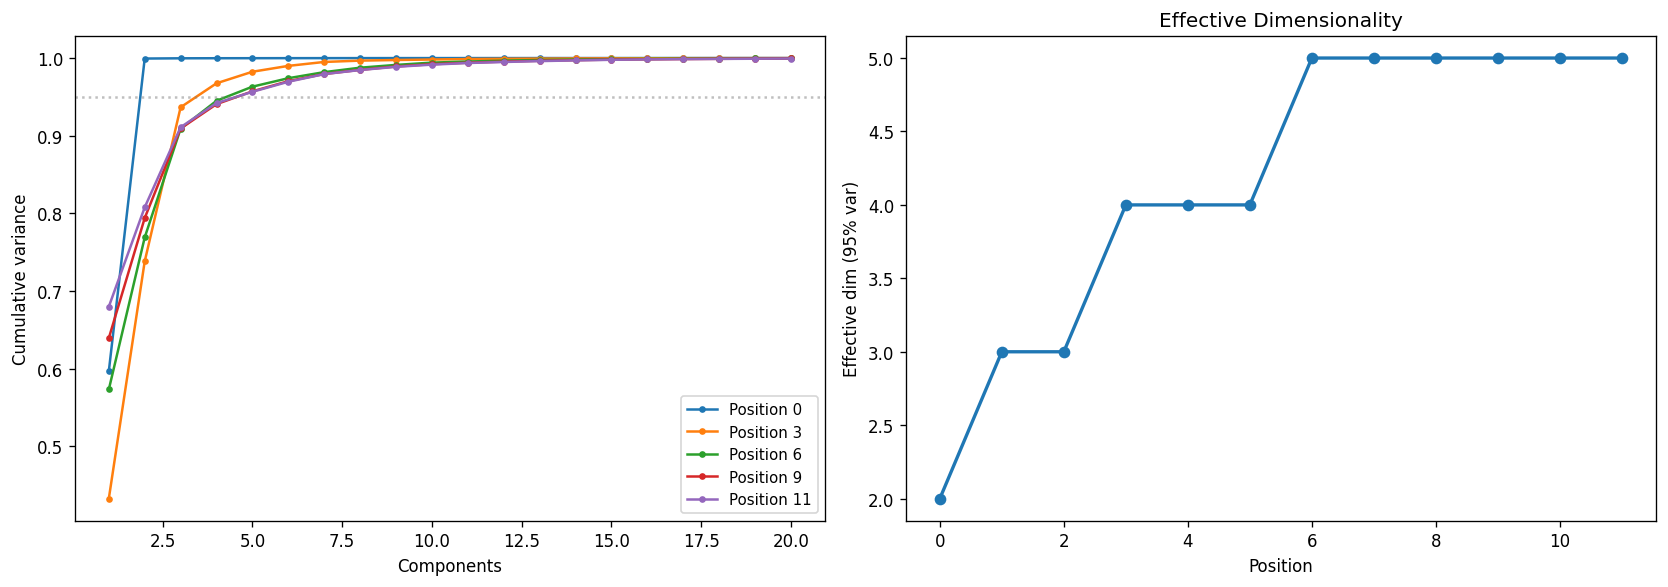

Effective dims: [2, 3, 3, 4, 4, 4, 5, 5, 5, 5, 5, 5]


In [21]:
# PCA spectrum
pca_results = pca_analysis(data['activations'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for pos in [0, T//4, T//2, 3*T//4, T-1]:
    cumvar = pca_results['cumulative_variance'][pos]
    ax.plot(range(1, len(cumvar)+1), cumvar, 'o-', label=f'Position {pos}', markersize=3)
ax.axhline(0.95, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Components'); ax.set_ylabel('Cumulative variance'); ax.legend(fontsize=9)

ax = axes[1]
eff_dims = [np.searchsorted(pca_results['cumulative_variance'][p], 0.95) + 1 for p in range(T)]
ax.plot(range(T), eff_dims, 'o-', linewidth=2)
ax.set_xlabel('Position'); ax.set_ylabel('Effective dim (95% var)')
ax.set_title('Effective Dimensionality')

plt.tight_layout()
plt.show()
print(f'Effective dims: {eff_dims}')

/Users/hughv/.pyenv/versions/3.13.5/lib/python3.13/site-packages/scipy/_lib/_util.py:1226: LinAlgWarning: Ill-conditioned matrix (rcond=4.38404e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/hughv/.pyenv/versions/3.13.5/lib/python3.13/site-packages/scipy/_lib/_util.py:1226: LinAlgWarning: Ill-conditioned matrix (rcond=5.58127e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/hughv/.pyenv/versions/3.13.5/lib/python3.13/site-packages/scipy/_lib/_util.py:1226: LinAlgWarning: Ill-conditioned matrix (rcond=4.7293e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/hughv/.pyenv/versions/3.13.5/lib/python3.13/site-packages/scipy/_lib/_util.py:1226: LinAlgWarning: Ill-conditioned matrix (rcond=4.38404e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/hughv/.pyenv/versions/3.13.5/lib/python3.13/site-packages/scipy/_lib/_util.py:1226: LinAlgWarning: Ill-conditi

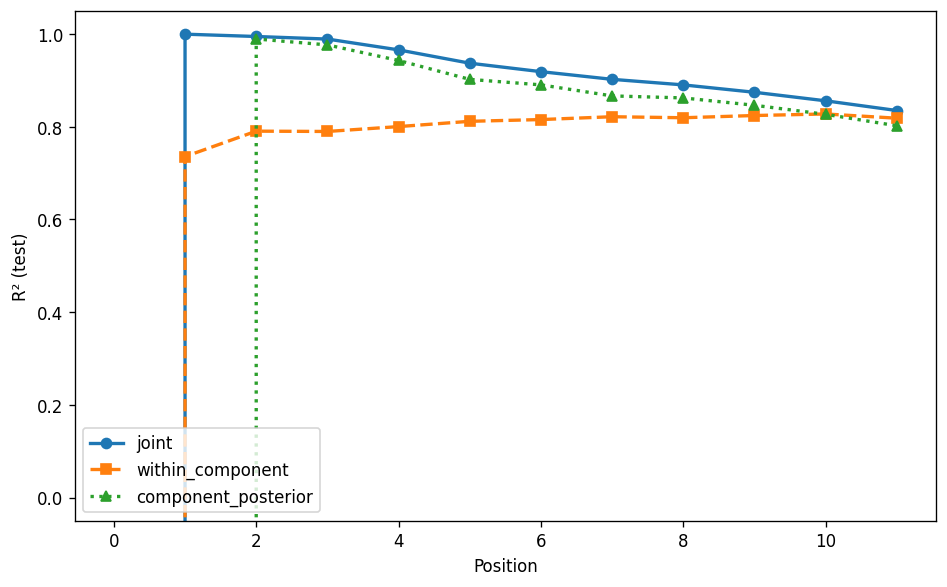

joint: R²=0.835 (last pos)
within_component: R²=0.819 (last pos)
component_posterior: R²=0.802 (last pos)


In [22]:
# Linear decodability of beliefs
reg_results = linear_regression_beliefs(data['activations'], data['beliefs'], comp_ids)

fig, ax = plt.subplots(figsize=(8, 5))
for name, style in [('joint', 'o-'), ('within_component', 's--'), ('component_posterior', '^:')]:
    ax.plot(reg_results[name], style, label=name, linewidth=2)
ax.set_xlabel('Position'); ax.set_ylabel('R² (test)'); ax.legend(); ax.set_ylim(-0.05, 1.05)
plt.tight_layout(); plt.show()

for name, r2 in reg_results.items():
    print(f'{name}: R²={r2[-1]:.3f} (last pos)')

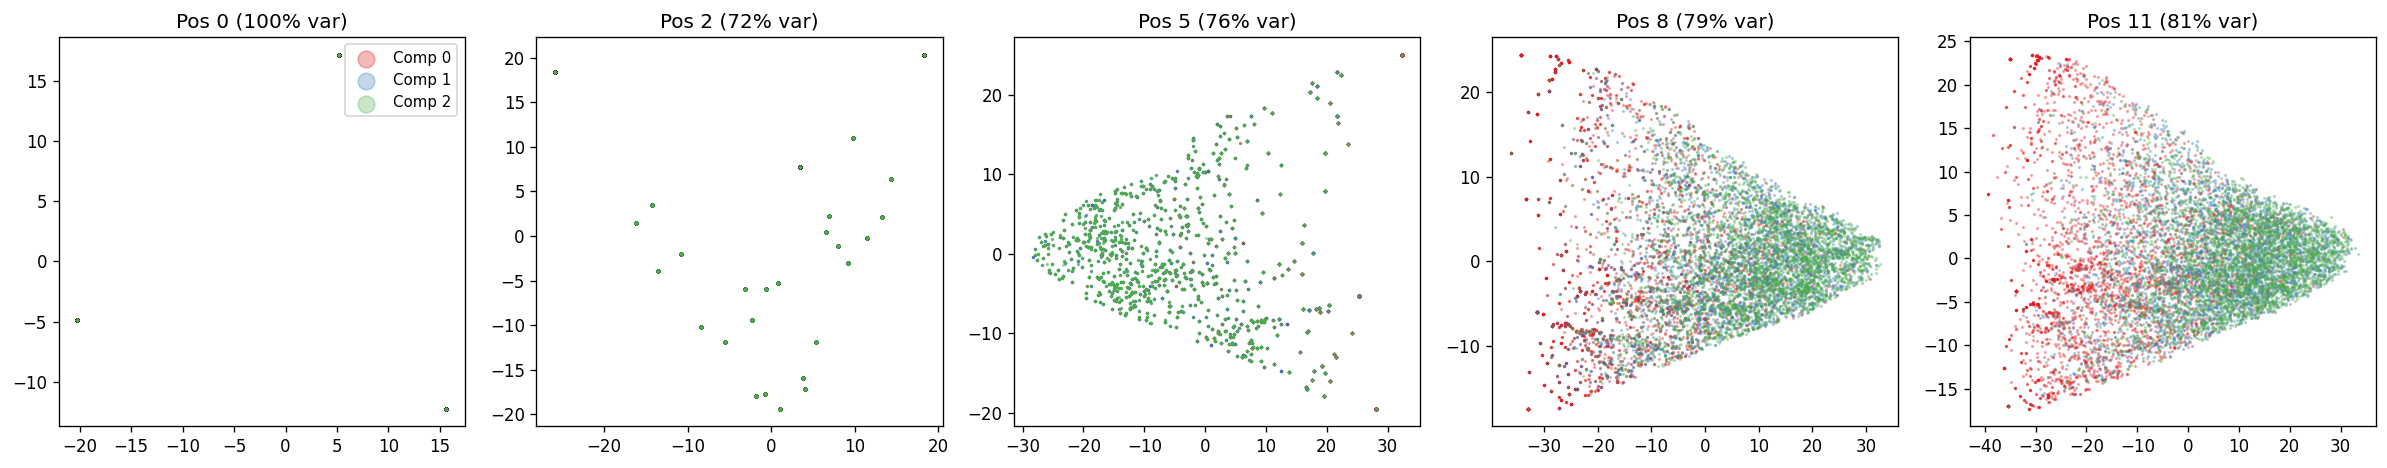

In [23]:
# PCA colored by component at multiple positions
colors_map = ['#e41a1c', '#377eb8', '#4daf4a']
positions = [0, 2, 5, 8, T-1]

fig, axes = plt.subplots(1, len(positions), figsize=(4*len(positions), 4))
for i, pos in enumerate(positions):
    ax = axes[i]
    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(act[:, pos, :])
    for k in range(3):
        mask = comp_ids == k
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=colors_map[k], s=1, alpha=0.3,
                   label=f'Comp {k}', rasterized=True)
    ax.set_title(f'Pos {pos} ({pca.explained_variance_ratio_[:2].sum()*100:.0f}% var)')
    if i == 0: ax.legend(markerscale=10, fontsize=9)
plt.tight_layout(); plt.show()

In [24]:
import plotly.graph_objects as go

# 3D PCA at last position, colored by component
pos = T - 1
pca3 = PCA(n_components=3)
X_3d = pca3.fit_transform(act[:, pos, :])
print(f'Top 3 PCs explain {pca3.explained_variance_ratio_[:3].sum()*100:.1f}% of variance at position {pos}')

color_map = {0: '#e41a1c', 1: '#377eb8', 2: '#4daf4a'}
fig = go.Figure()
for k in range(3):
    mask = comp_ids == k
    fig.add_trace(go.Scatter3d(
        x=X_3d[mask, 0], y=X_3d[mask, 1], z=X_3d[mask, 2],
        mode='markers', marker=dict(size=1.5, color=color_map[k], opacity=0.4),
        name=comp_names[k],
    ))
fig.update_layout(
    title=f'3D PCA of Residual Stream — Position {pos}',
    scene=dict(xaxis_title='PC1', yaxis_title='PC2', zaxis_title='PC3'),
    width=800, height=700,
)
fig.show()

Top 3 PCs explain 91.1% of variance at position 11


In [25]:
# 3D PCA colored by within-component belief (RGB = belief over 3 states)
wc = data['beliefs']['within_component'][:, pos, :]
rgb_colors = ['rgb({},{},{})'.format(int(r*255), int(g*255), int(b*255))
              for r, g, b in np.clip(wc, 0, 1)]

fig = go.Figure()
fig.add_trace(go.Scatter3d(
    x=X_3d[:, 0], y=X_3d[:, 1], z=X_3d[:, 2],
    mode='markers', marker=dict(size=1.5, color=rgb_colors, opacity=0.5),
    text=[f'Comp {c}' for c in comp_ids],
    showlegend=False,
))
fig.update_layout(
    title=f'3D PCA Colored by Within-Component Belief — Position {pos}',
    scene=dict(xaxis_title='PC1', yaxis_title='PC2', zaxis_title='PC3'),
    width=800, height=700,
)
fig.show()

In [ ]:
# Simplex fractal plots
comp_names = ['Comp 0 (α=0.9, x=0.1)', 'Comp 1 (α=0.7, x=0.2)', 'Comp 2 (α=0.5, x=0.3)']

for pos in [1, T//2, T-1]:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'Residual Stream → Simplex — Position {pos}', fontsize=13)
    for k in range(3):
        ax = axes[k]
        mask = comp_ids == k
        X = act[mask, pos, :]
        wc = data['beliefs']['within_component'][mask, pos, :]
        reg = Ridge(alpha=10.0)
        reg.fit(X, wc)
        proj = np.clip(reg.predict(X), 0, None)
        proj /= proj.sum(axis=1, keepdims=True)
        xy = barycentric_to_cartesian(proj)
        draw_simplex_outline(ax)
        ax.scatter(xy[:, 0], xy[:, 1], c=rgb_from_belief(wc), s=1, alpha=0.5, rasterized=True)
        ax.set_title(comp_names[k])
    plt.tight_layout(); plt.show()

In [ ]:
# Joint simplex at multiple positions: fit ONE linear map per position,
# project all components onto the same simplex
positions_to_show = [0, 2, 4, 7, T - 1]

from plotly.subplots import make_subplots

fig = make_subplots(
    rows=1, cols=len(positions_to_show),
    subplot_titles=[f'Position {p}' for p in positions_to_show],
    horizontal_spacing=0.03,
)

# Simplex outline vertices
sv = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2], [0, 0]])

for col, pos in enumerate(positions_to_show, 1):
    X_all = act[:, pos, :]
    wc_all = data['beliefs']['within_component'][:, pos, :]

    reg_joint = Ridge(alpha=10.0)
    reg_joint.fit(X_all, wc_all)
    proj_all = np.clip(reg_joint.predict(X_all), 0, None)
    proj_all /= proj_all.sum(axis=1, keepdims=True)
    xy_all = barycentric_to_cartesian(proj_all)

    r2 = reg_joint.score(X_all, wc_all)

    for k in range(3):
        mask = comp_ids == k
        wc_k = wc_all[mask]
        rgb_k = ['rgb({},{},{})'.format(int(r*255), int(g*255), int(b*255))
                 for r, g, b in np.clip(wc_k, 0, 1)]
        fig.add_trace(go.Scatter(
            x=xy_all[mask, 0], y=xy_all[mask, 1],
            mode='markers', marker=dict(size=2, color=rgb_k, opacity=0.5),
            name=comp_names[k], showlegend=(col == 1),
            legendgroup=f'comp{k}',
        ), row=1, col=col)

    # Simplex outline
    fig.add_trace(go.Scatter(x=sv[:, 0], y=sv[:, 1], mode='lines',
                             line=dict(color='black', width=1), showlegend=False),
                  row=1, col=col)

    # Add R² annotation
    fig.add_annotation(x=0.5, y=-0.05, text=f'R²={r2:.3f}',
                       showarrow=False, xref=f'x{col}', yref=f'y{col}', font=dict(size=11))

fig.update_layout(
    title='Joint Simplex: All Components in Shared Coordinates',
    width=300 * len(positions_to_show), height=400,
)
# Equal aspect ratio for all subplots
for i in range(1, len(positions_to_show) + 1):
    fig.update_xaxes(scaleanchor=f'y{i}', row=1, col=i, showticklabels=False)
    fig.update_yaxes(scaleratio=1, row=1, col=i, showticklabels=False)

fig.show()

In [28]:
# Subspace analysis: angles between per-component regression directions
pos = T - 1
weights = []
for k in range(3):
    mask = comp_ids == k
    reg = Ridge(alpha=1.0)
    reg.fit(act[mask, pos, :], data['beliefs']['within_component'][mask, pos, :])
    weights.append(reg.coef_)  # (3, 64)

# Principal angles between subspaces (via SVD of W_i^T @ W_j)
from scipy.linalg import svd
print('Principal angles between component belief subspaces (degrees):')
for i in range(3):
    for j in range(i+1, 3):
        U_i, _, _ = np.linalg.svd(weights[i], full_matrices=False)
        U_j, _, _ = np.linalg.svd(weights[j], full_matrices=False)
        cos_angles = svd(U_i @ U_j.T, compute_uv=False)
        angles = np.degrees(np.arccos(np.clip(cos_angles, -1, 1)))
        print(f'  Comp {i} vs Comp {j}: {np.round(angles, 1)}')

Principal angles between component belief subspaces (degrees):
  Comp 0 vs Comp 1: [0. 0. 0.]
  Comp 0 vs Comp 2: [0. 0. 0.]
  Comp 1 vs Comp 2: [0. 0. 0.]


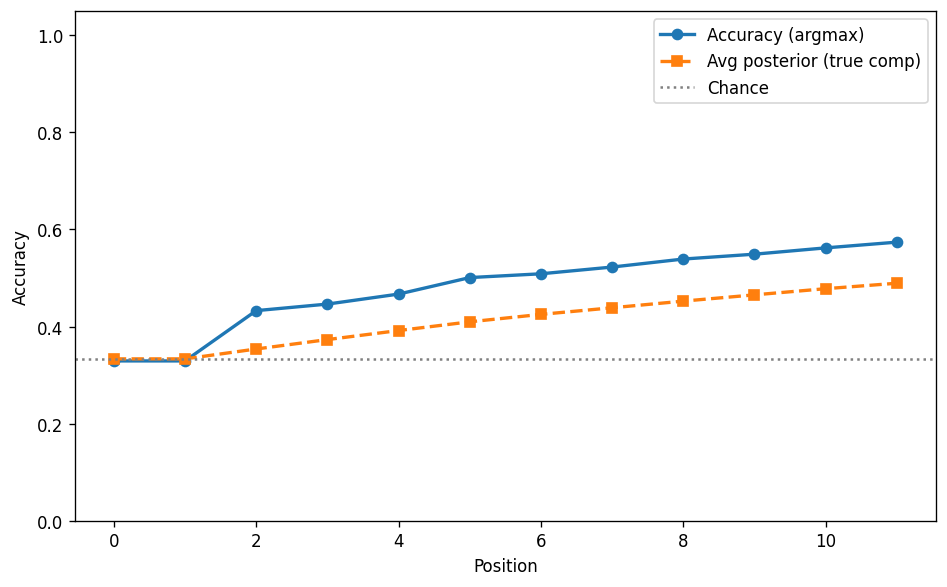

In [29]:
# Component identification (Bayesian)
beliefs = data['beliefs']
accuracy = np.array([(beliefs['component_posterior'][:, t, :].argmax(1) == comp_ids).mean() for t in range(T)])
avg_post = np.array([beliefs['component_posterior'][np.arange(len(comp_ids)), t, comp_ids].mean() for t in range(T)])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(accuracy, 'o-', label='Accuracy (argmax)', linewidth=2)
ax.plot(avg_post, 's--', label='Avg posterior (true comp)', linewidth=2)
ax.axhline(1/3, color='gray', linestyle=':', label='Chance')
ax.set_xlabel('Position'); ax.set_ylabel('Accuracy'); ax.legend(); ax.set_ylim(0, 1.05)
plt.tight_layout(); plt.show()

## Additional Analyses

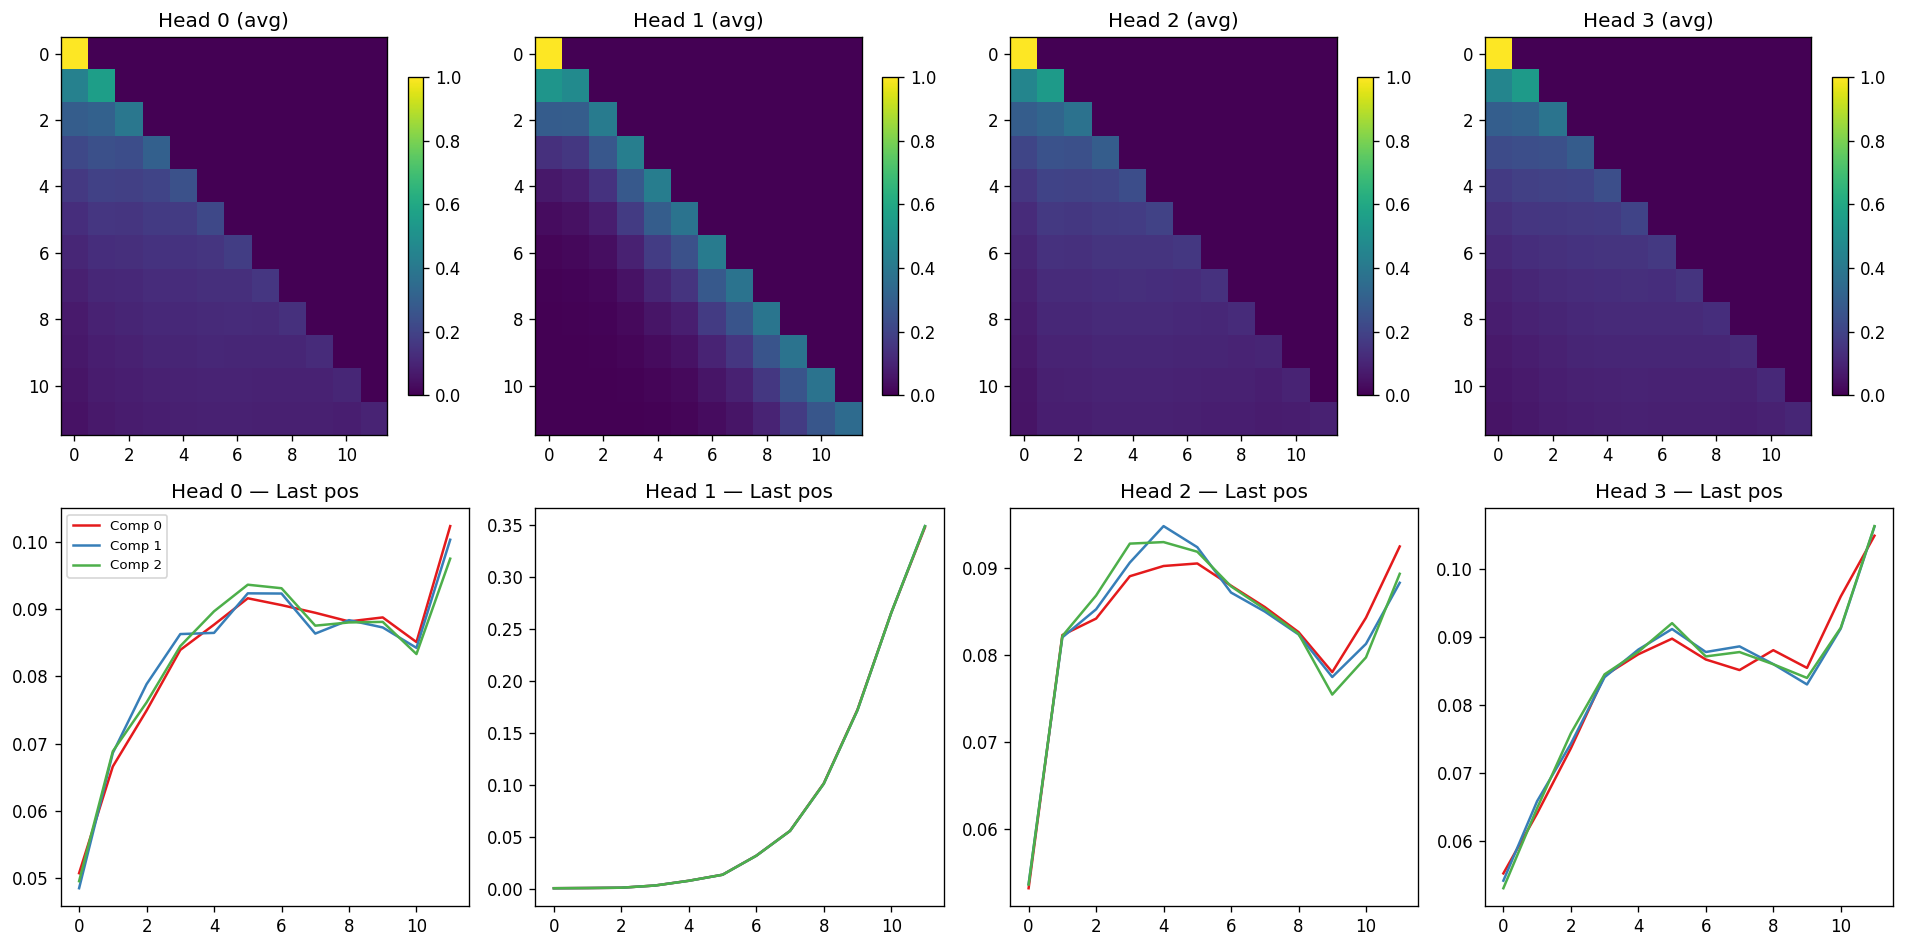

In [30]:
# Attention patterns per head, per component
attn = data['attn_weights']
H = attn.shape[1]

fig, axes = plt.subplots(2, H, figsize=(4*H, 8))
for h in range(H):
    axes[0, h].imshow(attn[:, h, :, :].mean(0), cmap='viridis', aspect='auto')
    axes[0, h].set_title(f'Head {h} (avg)')
    plt.colorbar(axes[0, h].images[0], ax=axes[0, h], shrink=0.8)
    for k in range(3):
        mask = comp_ids == k
        axes[1, h].plot(attn[mask, h, -1, :].mean(0), color=colors_map[k], label=f'Comp {k}')
    axes[1, h].set_title(f'Head {h} — Last pos')
    if h == 0: axes[1, h].legend(fontsize=8)
plt.tight_layout(); plt.show()

Computing per-component theoretical loss...


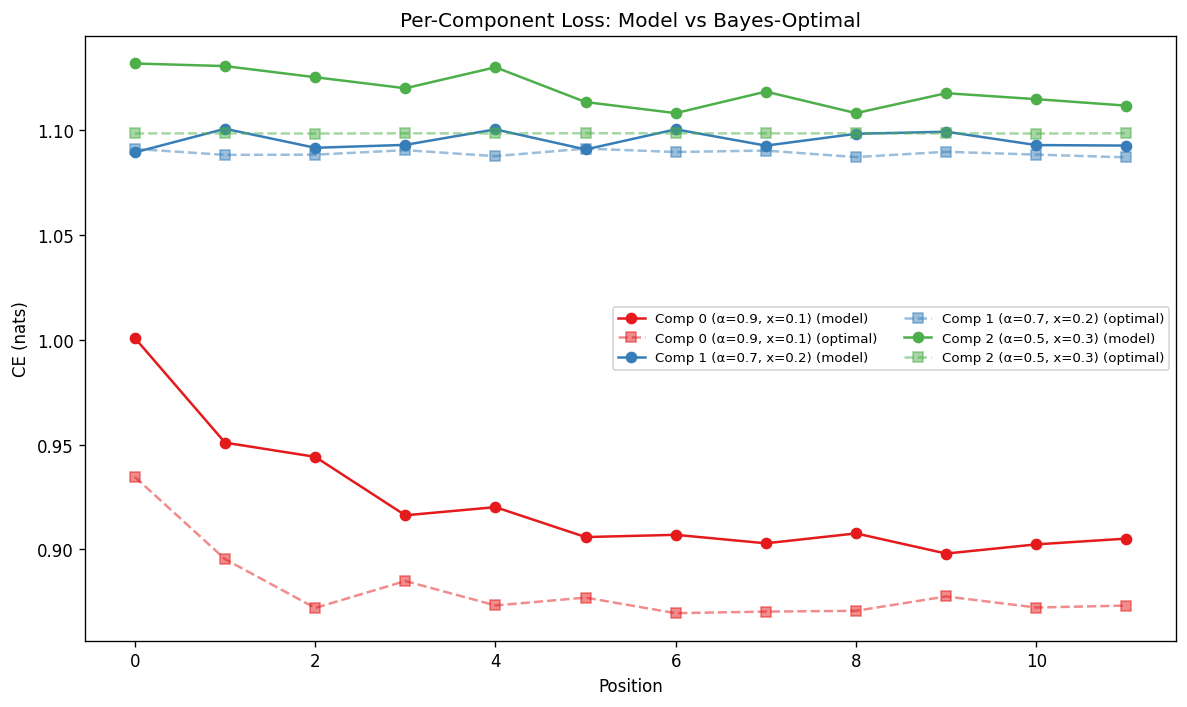

In [31]:
# Per-component loss decomposition
model.eval()
seq_len = config.context_length
n_eval = 5000

seqs, cids = generate_sequences(n_eval, seq_len + 1, rng=np.random.default_rng(123))
tokens = torch.tensor(seqs, dtype=torch.long, device=device)
with torch.no_grad():
    logits, _ = model(tokens[:, :-1])

model_loss = np.zeros((3, seq_len))
for k in range(3):
    mask = cids == k
    for t in range(seq_len):
        model_loss[k, t] = F.cross_entropy(logits[mask, t, :], tokens[mask, t+1], reduction='mean').item()

print('Computing per-component theoretical loss...')
theo_per_comp = compute_per_component_theoretical_loss(seq_len=seq_len, n_samples=10000)

colors = ['#e41a1c', '#377eb8', '#4daf4a']
fig, ax = plt.subplots(figsize=(10, 6))
for k in range(3):
    ax.plot(model_loss[k], 'o-', color=colors[k], label=f'{comp_names[k]} (model)')
    ax.plot(theo_per_comp[k], 's--', color=colors[k], alpha=0.5, label=f'{comp_names[k]} (optimal)')
ax.set_xlabel('Position'); ax.set_ylabel('CE (nats)')
ax.set_title('Per-Component Loss: Model vs Bayes-Optimal')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()